In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 


In [2]:
df=pd.read_csv("Rajshahi-Srimongals.csv")
df=df[df["Year"]<2019]

In [3]:
df.describe()

,Unnamed: 0,Year,Month,Date,ST-10,ST-30,ST-50,Temperature
count,13148.000000,13148.000000,13148.000000,13148.000000,13148.000000,13148.000000,13148.000000,13148.000000
mean,7304.000000,2009.500304,6.523654,15.728628,27.176202,27.429538,27.102829,24.835625
std,4443.339298,5.187934,3.448848,8.800000,4.767962,4.404951,4.046989,4.837913
min,0.000000,2001.000000,1.000000,1.000000,14.300000,15.600000,15.550000,8.500000
25%,3286.750000,2005.000000,4.000000,8.000000,23.250000,23.800000,23.700000,21.000000
50%,7304.000000,2009.500000,7.000000,16.000000,28.750000,29.000000,28.500000,26.500000
75%,11321.250000,2014.000000,10.000000,23.000000,30.950000,31.000000,30.400000,28.600000
max,14608.000000,2018.000000,12.000000,31.000000,38.000000,36.800000,36.300000,34.800000


In [4]:
dff=df.copy()

In [5]:


data_raj=dff[dff['Region']=='Rajshahi']
data_sri=dff[dff['Region']=='Srimongal']


In [6]:
df_raj=data_raj[['Temperature', 'ST-10', 'ST-30', 'ST-50']]
df_sri=data_sri[['Temperature', 'ST-10', 'ST-30', 'ST-50']]

In [7]:
df_sri.sample()

,Temperature,ST-10,ST-30,ST-50
2430,26.9,30.1,30.0,29.2


# Rajshahi Linear Regression

In [8]:
import math 



n=len(df_raj)

train_end=math.floor(n*0.80)


train_raj=df_raj.iloc[:train_end]
val_raj=df_raj.iloc[train_end:]

X_train_raj=train_raj[['Temperature']]
y_train_raj=train_raj[['ST-30']]

X_val_raj=val_raj[['Temperature']]
y_val_raj=val_raj[['ST-30']]


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error


In [10]:
lr_raj=LinearRegression()
lr_raj.fit(X_train_raj,y_train_raj)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
y_raj_pred=lr_raj.predict(X_val_raj)
mae_raj=round(mean_absolute_error(y_val_raj,y_raj_pred),3)
mse_raj=mean_squared_error(y_val_raj,y_raj_pred)
rmse_raj=round(mse_raj**0.5,3)
r2_raj=round(r2_score(y_val_raj,y_raj_pred),2)


print("\nRAJSHAHI\n")
print(f"MAE: {mae_raj}\nRMSE: {rmse_raj}\nR2 SCORE: {r2_raj}")


RAJSHAHI

MAE: 1.092
RMSE: 1.386
R2 SCORE: 0.9


In [12]:
m_raj=lr_raj.coef_[0][0]
m_raj

0.9187959001677919

In [13]:
c_raj=lr_raj.intercept_[0]
c_raj

4.4519933400238685

In [14]:
y_val_raj.shape

(1315, 1)

C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_13260\2140514160.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot([y_val_raj.min(), y_val_raj.max()],


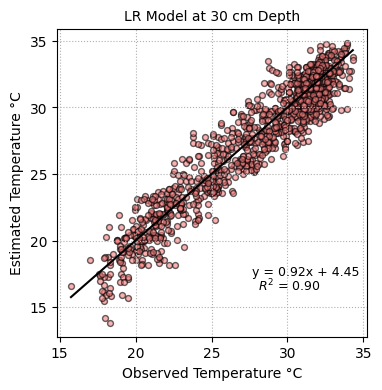

In [15]:
y_val_rajj= y_val_raj[400:1200]
y_raj_predd = y_raj_pred[400:1200]
plt.figure(figsize=(4,4))
plt.scatter(y_val_raj, y_raj_pred,s=18, c='#f57e7e', alpha=0.6, edgecolors='black',marker='o')
plt.plot([y_val_raj.min(), y_val_raj.max()],
         [y_val_raj.min(), y_val_raj.max()],
         'r-', lw=1.5, label="1:1 line",c='black')

x_vals = np.linspace(y_val_raj.min(), y_val_raj.max(), 100)
#plt.plot(x_vals, m_raj * x_vals + c_raj, 'b-', lw=2, label="Best fit line",c='#320d3e')

plt.text(0.63, 0.2, f'y = {m_raj:.2f}x + {c_raj:.2f}', transform=plt.gca().transAxes, fontsize=9)
plt.text(0.65, 0.15, f'$R^2$ = {r2_raj:.2f}', transform=plt.gca().transAxes, fontsize=9)

plt.xlabel('Observed Temperature °C', fontsize=10)
plt.ylabel('Estimated Temperature °C', fontsize=10)
plt.title('LR Model at 30 cm Depth', fontsize=10)
plt.grid(ls=':')
plt.show()

# Srimongal Linear Regression 

In [16]:
import math

m = len(df_sri)

train_end_sri = math.floor(m * 0.80)

train_sri = df_sri.iloc[:train_end_sri]
val_sri = df_sri.iloc[train_end_sri:]


In [17]:
val_sri.shape

(1315, 4)

In [18]:
X_train_sri = train_sri[['Temperature']]
y_train_sri = train_sri[['ST-30']]

X_val_sri = val_sri[['Temperature']]
y_val_sri = val_sri[['ST-30']]



In [19]:
Q1 = X_train_sri['Temperature'].quantile(0.25)
Q3 = X_train_sri['Temperature'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
X_train_sri['Temperature'] = X_train_sri['Temperature'].clip(lower=lower_bound, upper=upper_bound)


C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_13260\970763780.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_sri['Temperature'] = X_train_sri['Temperature'].clip(lower=lower_bound, upper=upper_bound)


In [20]:
X_train_sri.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5259 entries, 0 to 5258
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  5259 non-null   float64
dtypes: float64(1)
memory usage: 82.2 KB


In [21]:
lr_sri = LinearRegression()
lr_sri.fit(X_train_sri, y_train_sri)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
y_sri_pred=lr_sri.predict(X_val_sri)
mae_sri=round(mean_absolute_error(y_val_sri,y_sri_pred),3)
mse_sri=mean_squared_error(y_val_sri,y_sri_pred)
rmse_sri=round(mse_sri**0.5,3)
r2_sri=round(r2_score(y_val_sri,y_sri_pred),2)


print("\nSRIMONGAL\n")
print(f"MAE: {mae_sri}\nRMSE: {rmse_sri}\nR2 SCORE: {r2_sri}")


SRIMONGAL

MAE: 0.823
RMSE: 1.198
R2 SCORE: 0.9


In [23]:
m_sri=lr_sri.coef_[0][0]
m_sri

0.8373272957168734

In [24]:
c_sri=lr_sri.intercept_[0]
c_sri

6.7400338703622715

C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_13260\116583248.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot([y_val_sri.min(), y_val_sri.max()],


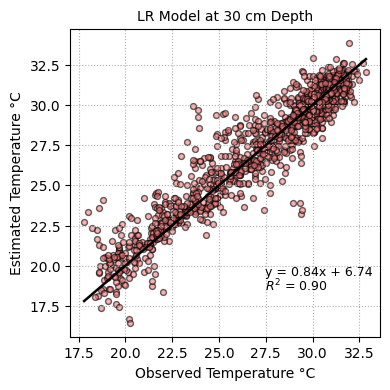

In [25]:

plt.figure(figsize=(4,4))
plt.scatter(y_val_sri, y_sri_pred,s=18, c='#f57e7e', alpha=0.6, edgecolors='black',marker='o')
plt.plot([y_val_sri.min(), y_val_sri.max()],
         [y_val_sri.min(), y_val_sri.max()],
         'r-', lw=1.8, label="1:1 line",c='BLACK')

x_vals_sri = np.linspace(y_val_sri.min(), y_val_sri.max(), 100)
#plt.plot(x_vals_sri, m_sri * x_vals_sri + c_sri, 'b-', lw=2, label="Best fit line" ,c='#320d3e')

plt.text(0.63, 0.2, f'y = {m_sri:.2f}x + {c_sri:.2f}', transform=plt.gca().transAxes, fontsize=9)
plt.text(0.63, 0.15, f'$R^2$ = {r2_sri:.2f}', transform=plt.gca().transAxes, fontsize=9)

plt.xlabel('Observed Temperature °C', fontsize=10)
plt.ylabel('Estimated Temperature °C', fontsize=10)
plt.title('LR Model at 30 cm Depth', fontsize=10)
plt.grid(ls=':')
plt.show()
